# 05 — Custo

A quarta dimensão do estudo: **custo monetário por resposta**. Junto com a latência, é medido apenas no canal API — o chat web tem assinatura mensal, não cobra por chamada, e qualquer alocação seria arbitrária.

O custo é calculado em dólares por resposta, usando os preços tabelados de cada provedor para `input_tokens` (prompt do sistema + pergunta + retornos da ferramenta de busca) e `output_tokens` (raciocínio interno + chamadas à ferramenta + texto final). **A separação entre output e resposta-tiktoken importa aqui**: o fluxo interno é cobrado integralmente, mesmo que o usuário só veja o texto final.

A variação total no estudo é dramática — **75×** entre o modelo mais barato e o mais caro. Por isso, escala log será obrigatória em vários gráficos.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from utils import (carregar_dados, agrega_por_modelo, estilo_padrao,
                   CORES_PROVEDOR, ORDEM_MODELOS, MARKER_API,
                   titulo_acima, anota_sem_sobrepor, bootstrap_ic)

estilo_padrao()
df = carregar_dados()
mestre = agrega_por_modelo(df)

df_api = df[df['origem'] == 'API'].copy()
mestre_api = mestre[mestre['origem'] == 'API'].copy()

ORDEM_API = [m for m in ORDEM_MODELOS if m in mestre_api.index]

# Estatísticas de custo
print(f'Custo médio mais baixo: ${mestre_api["custo_usd"].min():.4f}  ({mestre_api["custo_usd"].idxmin()})')
print(f'Custo médio mais alto:  ${mestre_api["custo_usd"].max():.4f}  ({mestre_api["custo_usd"].idxmax()})')
print(f'Razão:                  {mestre_api["custo_usd"].max() / mestre_api["custo_usd"].min():.0f}×')

Custo médio mais baixo: $0.0014  (GPT-4o mini)
Custo médio mais alto:  $0.1070  (Claude Opus 4.7)
Razão:                  74×


## 1. Ranking de custo (escala log)

Custo médio por resposta. **Escala log no eixo Y** — em escala linear, DeepSeek v4 Flash (US$ 0,002) e Claude Opus 4.7 (US$ 0,107) literalmente não cabem no mesmo gráfico.


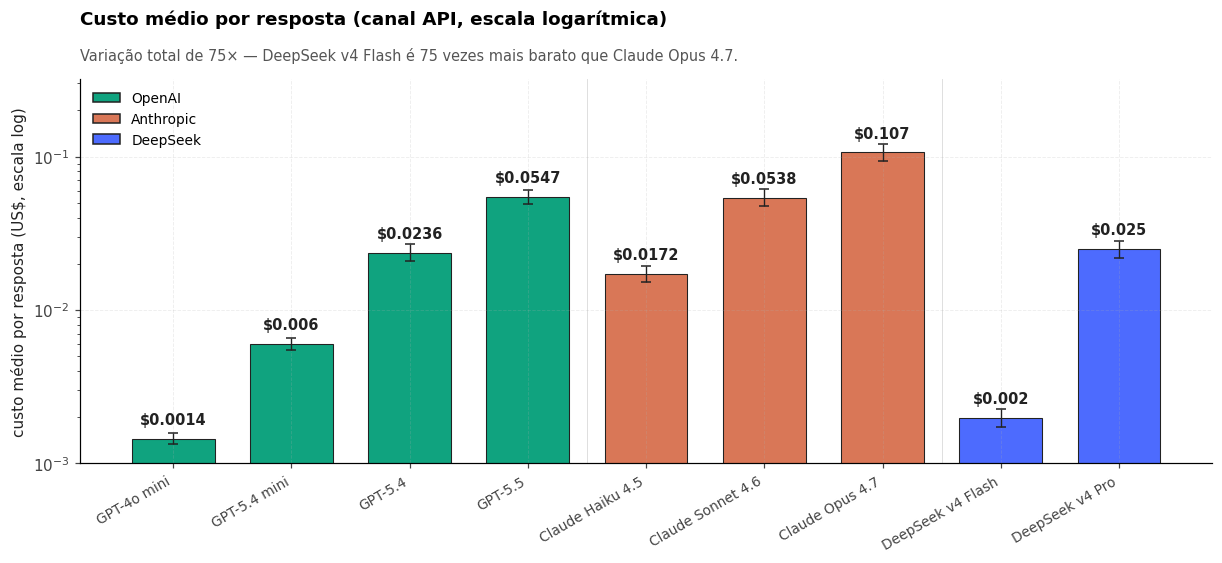

In [2]:
fig, ax = plt.subplots(figsize=(11, 5.0), layout='constrained')

xs = np.arange(len(ORDEM_API))
valores = mestre_api.loc[ORDEM_API, 'custo_usd'].values
cores = mestre_api.loc[ORDEM_API, 'cor'].values

bars = ax.bar(xs, valores, color=cores, edgecolor='#222',
              linewidth=0.7, width=0.7)

ax.set_yscale('log')

# IC bootstrap
for i, m in enumerate(ORDEM_API):
    s = df_api.loc[df_api['modelo_display'] == m, 'custo_estimado_usd']
    lo, hi = bootstrap_ic(s, n_boot=2000)
    ax.errorbar(i, s.mean(), yerr=[[s.mean()-lo],[hi-s.mean()]],
                fmt='none', ecolor='#222', elinewidth=0.9, capsize=3, zorder=4)

# Rótulos
for x, v in zip(xs, valores):
    ax.text(x, v * 1.18, f'${v:.4f}'.rstrip('0').rstrip('.') or '$0',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#222')

# Separadores
last = None
for i, p in enumerate(mestre_api.loc[ORDEM_API, 'provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(xs)
ax.set_xticklabels(ORDEM_API, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('custo médio por resposta (US$, escala log)')
ax.set_ylim(0.001, max(valores) * 3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],   edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'], edgecolor='#222', label='DeepSeek'),
], loc='upper left', fontsize=9)

titulo_acima(ax,
    'Custo médio por resposta (canal API, escala logarítmica)',
    'Variação total de 75× — DeepSeek v4 Flash é 75 vezes mais barato que Claude Opus 4.7.')

plt.show()

**Mesmo em log, a escala não esconde a hierarquia.**

- **Os baratos**: DeepSeek v4 Flash (US$ 0,0020) e GPT-4o mini (US$ 0,0014) — basicamente gratuitos no volume médio.
- **A faixa "consumo razoável"**: GPT-5.4 mini (US$ 0,006), DeepSeek v4 Pro (US$ 0,025), GPT-5.4 (US$ 0,024). Para uma operação que faz 10 mil consultas/mês, isso é US$ 60–250.
- **Os caros**: Claude Sonnet 4.6 (US$ 0,054), GPT-5.5 (US$ 0,055), Claude Haiku 4.5 (US$ 0,017 — surpreendentemente alto para um "modelo leve") e **Claude Opus 4.7 (US$ 0,107)** — o pico. Em 10 mil consultas/mês: US$ 540 a US$ 1 070.

A surpresa do Haiku reaparece. **Apesar do nome de modelo barato**, o Haiku 4.5 acaba custando perto do GPT-5.4 médio. Mesma causa da latência: o Haiku faz mais iterações com a ferramenta antes de chegar à resposta, multiplicando o consumo de tokens.


## 2. Onde os tokens vão: resposta visível vs fluxo interno

A coluna `output_tokens` da API soma três fontes: raciocínio interno do modelo, parâmetros de chamadas à ferramenta de busca, e o texto final entregue ao usuário (este último contado com tiktoken). Decompor isso é essencial para entender por que o custo dispara — em vários modelos, a maior parte do que se paga é texto que o usuário **nunca lê**.


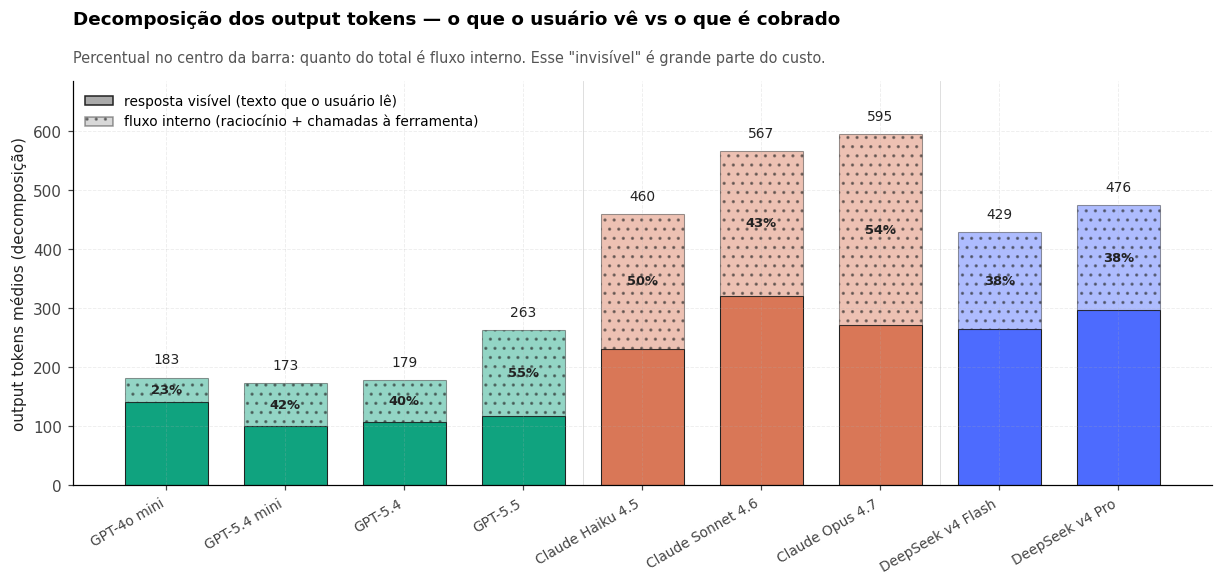

In [3]:
# Decomposição: resposta visível vs fluxo interno
mestre_api['tokens_fluxo_interno_medio'] = (
    df_api.groupby('modelo_display')['tokens_fluxo_interno'].mean()
)
mestre_api['tokens_resp_medio'] = mestre_api['tokens_resp']

fig, ax = plt.subplots(figsize=(11, 5.2), layout='constrained')

xs = np.arange(len(ORDEM_API))
v_resp  = mestre_api.loc[ORDEM_API, 'tokens_resp_medio'].values
v_fluxo = mestre_api.loc[ORDEM_API, 'tokens_fluxo_interno_medio'].values

cores = mestre_api.loc[ORDEM_API, 'cor'].values

# Barras empilhadas: resposta visível embaixo (sólida), fluxo interno em cima (com hatch ..)
b1 = ax.bar(xs, v_resp, color=cores, edgecolor='#222', linewidth=0.7, width=0.7,
            label='resposta visível (tiktoken)')
b2 = ax.bar(xs, v_fluxo, bottom=v_resp,
            color=cores, edgecolor='#222', linewidth=0.7, width=0.7,
            alpha=0.45, hatch='..',
            label='fluxo interno (raciocínio + tool-calls)')

# Rótulo do total no topo
for x, vr, vf in zip(xs, v_resp, v_fluxo):
    total = vr + vf
    ax.text(x, total + 18, f'{total:.0f}', ha='center', va='bottom',
            fontsize=9, color='#222')
    # Percentual de fluxo interno
    pct = vf / total * 100 if total else 0
    ax.text(x, vr + vf / 2, f'{pct:.0f}%',
            ha='center', va='center', fontsize=8.5, color='#222',
            fontweight='bold')

# Separadores
last = None
for i, p in enumerate(mestre_api.loc[ORDEM_API, 'provedor'].values):
    if last is not None and p != last:
        ax.axvline(i - 0.5, color='#ddd', lw=0.6, zorder=0)
    last = p

ax.set_xticks(xs)
ax.set_xticklabels(ORDEM_API, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('output tokens médios (decomposição)')
ax.set_ylim(0, max(v_resp + v_fluxo) * 1.15)

# Legenda customizada
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#aaa', edgecolor='#222', label='resposta visível (texto que o usuário lê)'),
    Patch(facecolor='#aaa', edgecolor='#222', alpha=0.45, hatch='..',
          label='fluxo interno (raciocínio + chamadas à ferramenta)'),
], loc='upper left', fontsize=9)

titulo_acima(ax,
    'Decomposição dos output tokens — o que o usuário vê vs o que é cobrado',
    'Percentual no centro da barra: quanto do total é fluxo interno. Esse "invisível" é grande parte do custo.')

plt.show()

**O fluxo interno domina o consumo na maioria dos modelos.**

- Em **GPT-4o mini, GPT-5.4 mini e GPT-5.4**, mais de **50%** do total de output tokens é fluxo interno — texto que o usuário nunca vê.
- Em **GPT-5.5**, o fluxo interno também é alto em termos absolutos (~150 tokens), mas a resposta visível ainda fica perto do mesmo tamanho. Razão da precisão alta: mais raciocínio por resposta.
- Os modelos **Anthropic e DeepSeek** mostram um padrão mais equilibrado: 30–40% de fluxo interno. A resposta visível é grande o bastante para não ser sufocada pelas chamadas à ferramenta.

**A implicação prática.** Otimizar a resposta visível (instruções de concisão no prompt, por exemplo) tem efeito limitado sobre o custo — o que move o ponteiro é controlar o número de chamadas à ferramenta. Modelos que "iteram menos" custam menos *e* são mais rápidos, como o GPT-5.4 mini.


## 3. Precisão × custo: o segundo trade-off

Análogo do gráfico precisão × latência, com custo em escala log. **Canto superior esquerdo é o ideal**: alta precisão, baixo custo.


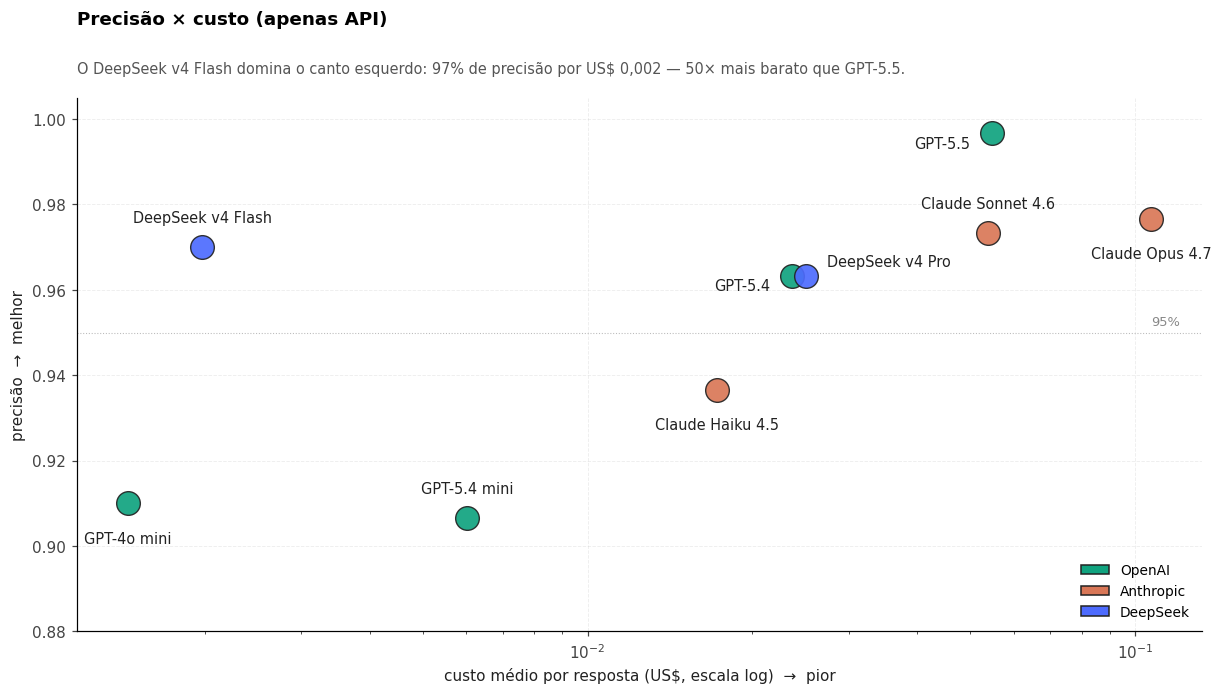

In [4]:
fig, ax = plt.subplots(figsize=(11, 6.2), layout='constrained')

for nome, row in mestre_api.iterrows():
    ax.scatter(row['custo_usd'], row['precisao'],
               s=240, color=row['cor'], marker=MARKER_API,
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

ax.set_xscale('log')

ax.axhline(0.95, ls=':', color='#bbb', lw=0.7, zorder=1)
ax.text(0.98, 0.951, '95%', fontsize=8.5, color='#888',
        transform=ax.get_yaxis_transform(), va='bottom', ha='right')

anota_sem_sobrepor(ax,
    mestre_api['custo_usd'].values,
    mestre_api['precisao'].values,
    mestre_api.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 0, -18),
        'GPT-5.4 mini':       ( 0,  14),
        'GPT-5.4':            (-14,  -2),
        'GPT-5.5':            (-14,  -2),
        'Claude Haiku 4.5':   ( 0, -18),
        'Claude Sonnet 4.6':  ( 0,  14),
        'Claude Opus 4.7':    ( 0, -18),
        'DeepSeek v4 Flash':  ( 0,  14),
        'DeepSeek v4 Pro':    ( 14,   4),
    })

ax.set_ylim(0.88, 1.005)
ax.set_xlabel('custo médio por resposta (US$, escala log)  →  pior')
ax.set_ylabel('precisão  →  melhor')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],   edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'], edgecolor='#222', label='DeepSeek'),
], loc='lower right', fontsize=9)

titulo_acima(ax,
    'Precisão × custo (apenas API)',
    'O DeepSeek v4 Flash domina o canto esquerdo: 97% de precisão por US$ 0,002 — 50× mais barato que GPT-5.5.')

plt.show()

**O ponto que mais salta.** **DeepSeek v4 Flash** ocupa o canto superior esquerdo praticamente sozinho — 97,0% de precisão por **US$ 0,002**. Modelos com precisão comparável (Claude Opus 4.7, Sonnet 4.6, GPT-5.4) custam de 12× a 53× mais.

**Por provedor.**

- **OpenAI** tem dispersão grande: GPT-4o mini é barato mas só atinge 91%. GPT-5.5 atinge 99,7% mas custa mais de 25× o preço.
- **Anthropic** está toda concentrada em uma faixa estreita de precisão alta (94–98%) com custos médios a altos.
- **DeepSeek** é dominante em custo: ambos os modelos custam menos que qualquer Claude ou GPT premium, com precisão próxima ao topo.

**Que decisão isso sugere?** Para um sistema sensível a custo onde 97% de precisão é aceitável, **DeepSeek v4 Flash é a escolha óbvia**. Para os 2,7 pp finais até o topo (99,7% do GPT-5.5), paga-se uma multa de 25× em dinheiro e 2× em latência. Se a aplicação for tolerante a erros (atendimento conversacional, sumarização exploratória), Flash; se for crítica (resposta legal, decisão financeira), GPT-5.5 ainda compensa.


## 4. Latência × custo: quem é caro também demora?

Olhar pareado entre as duas dimensões "de operação" (sem precisão e concisão, que são "de qualidade"). Se latência e custo correlacionarem fortemente, isso significa que o fluxo interno é a mesma raiz dos dois — o modelo decidir parar de iterar com a ferramenta resolveria ambos os problemas de uma vez.


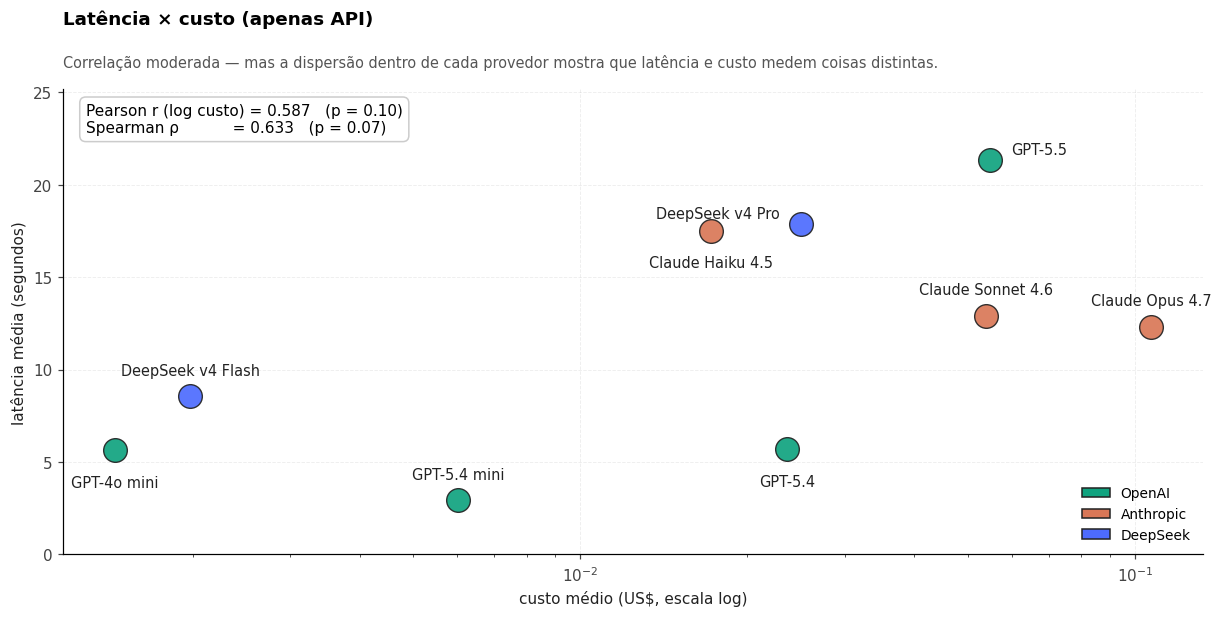

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5), layout='constrained')

for nome, row in mestre_api.iterrows():
    ax.scatter(row['custo_usd'], row['latencia_s'],
               s=240, color=row['cor'], marker=MARKER_API,
               edgecolor='#222', linewidth=0.9, zorder=3, alpha=0.92)

ax.set_xscale('log')

r_p, p_p = stats.pearsonr(np.log10(mestre_api['custo_usd']), mestre_api['latencia_s'])
r_s, p_s = stats.spearmanr(mestre_api['custo_usd'], mestre_api['latencia_s'])

anota_sem_sobrepor(ax,
    mestre_api['custo_usd'].values,
    mestre_api['latencia_s'].values,
    mestre_api.index.tolist(),
    fontsize=9.5,
    offsets_manuais={
        'GPT-4o mini':        ( 0, -16),
        'GPT-5.4 mini':       ( 0,  12),
        'GPT-5.4':            ( 0, -16),
        'GPT-5.5':            ( 14,  2),
        'Claude Haiku 4.5':   ( 0, -16),
        'Claude Sonnet 4.6':  ( 0,  12),
        'Claude Opus 4.7':    ( 0,  12),
        'DeepSeek v4 Flash':  ( 0,  12),
        'DeepSeek v4 Pro':    (-14,  2),
    })

ax.set_ylim(0, mestre_api['latencia_s'].max() * 1.18)
ax.set_xlabel('custo médio (US$, escala log)')
ax.set_ylabel('latência média (segundos)')

ax.text(0.02, 0.97,
        f'Pearson r (log custo) = {r_p:.3f}   (p = {p_p:.2f})\n'
        f'Spearman ρ           = {r_s:.3f}   (p = {p_s:.2f})',
        transform=ax.transAxes, va='top', ha='left',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#ccc'))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=CORES_PROVEDOR['OpenAI'],   edgecolor='#222', label='OpenAI'),
    Patch(facecolor=CORES_PROVEDOR['Anthropic'], edgecolor='#222', label='Anthropic'),
    Patch(facecolor=CORES_PROVEDOR['DeepSeek'], edgecolor='#222', label='DeepSeek'),
], loc='lower right', fontsize=9)

titulo_acima(ax,
    'Latência × custo (apenas API)',
    'Correlação moderada — mas a dispersão dentro de cada provedor mostra que latência e custo medem coisas distintas.')

plt.show()

**Correlação moderada.** Custo e latência caminham juntos, mas longe de serem proxy um do outro. Há casos esclarecedores:

- **Claude Haiku 4.5** demora 17 s mas custa US$ 0,017 — caro para o tempo gasto, porque tokens da Anthropic são caros mesmo em modelo "leve".
- **GPT-5.4 mini** é o ponto ideal nessa dimensão: 3 s e US$ 0,006. Latência ínfima por preço também baixo.
- **DeepSeek v4 Pro** demora 17,9 s e custa US$ 0,025 — pior que Flash em ambos os eixos, sem ganhar precisão suficiente para justificar.

---

As quatro dimensões agora foram cobertas separadamente. O notebook 06 sintetiza tudo: o gráfico das quatro dimensões num plot integrado, score híbrido transparente em três variantes, e a recomendação final por perfil de uso.
